In [57]:
import kagglehub
import os
import pandas as pd
import glob
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

In [58]:


# Download latest version
path = kagglehub.dataset_download("PromptCloudHQ/imdb-data")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\naman yadav\.cache\kagglehub\datasets\PromptCloudHQ\imdb-data\versions\1


In [59]:
csv_files = glob.glob(os.path.join(path, "*.csv"))
df = pd.read_csv(csv_files[0])

In [60]:
df.shape

(1000, 12)

In [61]:
df.isnull().sum()

Rank                    0
Title                   0
Genre                   0
Description             0
Director                0
Actors                  0
Year                    0
Runtime (Minutes)       0
Rating                  0
Votes                   0
Revenue (Millions)    128
Metascore              64
dtype: int64

In [62]:
df['Revenue (Millions)'] = df['Revenue (Millions)'].fillna('np.nan')

In [63]:
df['Metascore'] = pd.to_numeric(df['Metascore'], errors='coerce')
df['Metascore'] = df['Metascore'].interpolate(method='linear', limit_direction='forward')

In [64]:
df.duplicated().sum()

np.int64(0)

In [65]:
top10_runtime = df.nlargest(10, 'Runtime (Minutes)').set_index('Title')

Text(0.5, 1.0, 'Top 10 Movies with Longest Runtime')

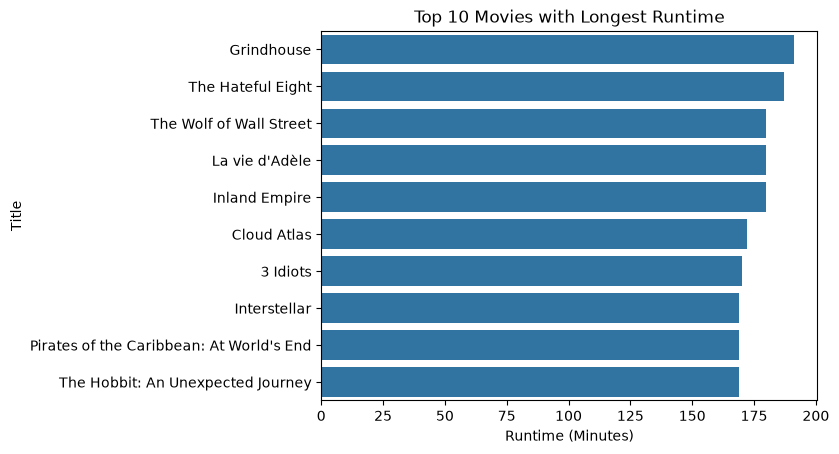

In [66]:
plt.Figure(figsize=(10, 6))
top10_runtime = df.nlargest(10, 'Runtime (Minutes)').set_index('Title')
sns.barplot(y=top10_runtime.index, x=top10_runtime['Runtime (Minutes)'])
plt.title('Top 10 Movies with Longest Runtime')

In [67]:
top10_rating = df.nlargest(10, 'Rating').set_index('Title')

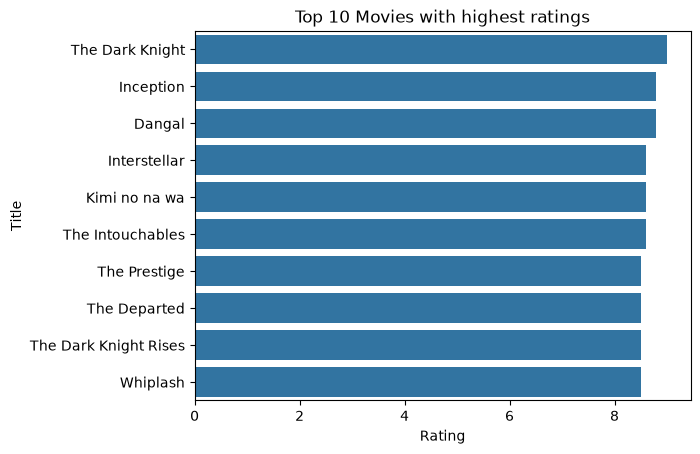

In [68]:
plt.Figure(figsize=(10, 6))
top10_rating = df.nlargest(10, 'Rating').set_index('Title')
sns.barplot(x=top10_rating['Rating'], y=top10_rating.index)
plt.title('Top 10 Movies with highest ratings')
plt.show()


In [69]:
top10_revenue = df.nlargest(10, 'Revenue (Millions)').set_index('Title')

TypeError: Column 'Revenue (Millions)' has dtype object, cannot use method 'nlargest' with this dtype

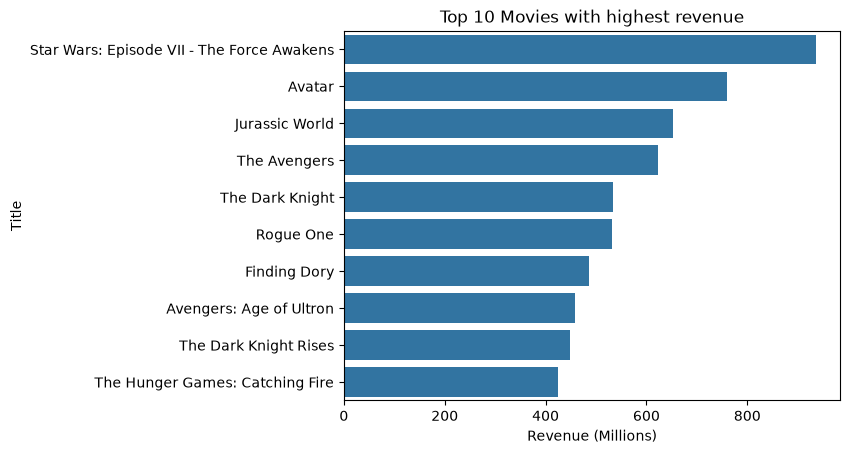

In [ ]:
plt.Figure(figsize=(10, 6))
df['Revenue (Millions)'] = pd.to_numeric(df['Revenue (Millions)'].replace('np.nan', np.nan), errors='coerce')
top10_revenue = df.nlargest(10, 'Revenue (Millions)').set_index('Title')
sns.barplot(x=top10_revenue['Revenue (Millions)'], y=top10_revenue.index)
plt.title('Top 10 Movies with highest revenue')
plt.show()


In [ ]:
top10_votes = df.nlargest(10,'votes').set_index('Title')

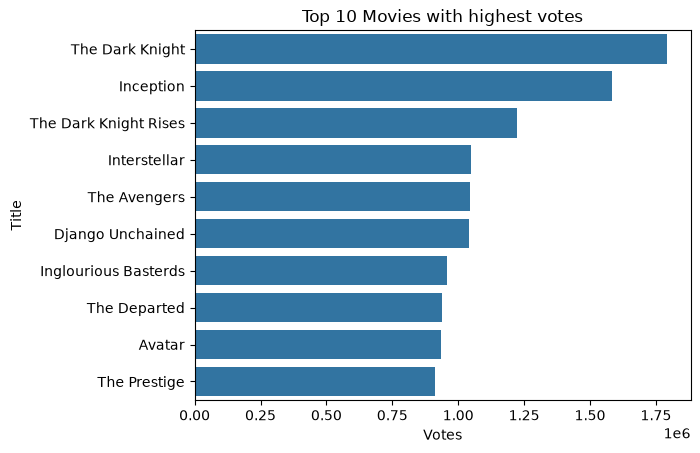

In [ ]:
plt.Figure(figsize=(10, 6))
top10_votes = df.nlargest(10, 'Votes').set_index('Title')
sns.barplot(x=top10_votes['Votes'], y=top10_votes.index)
plt.title('Top 10 Movies with highest votes')
plt.show()


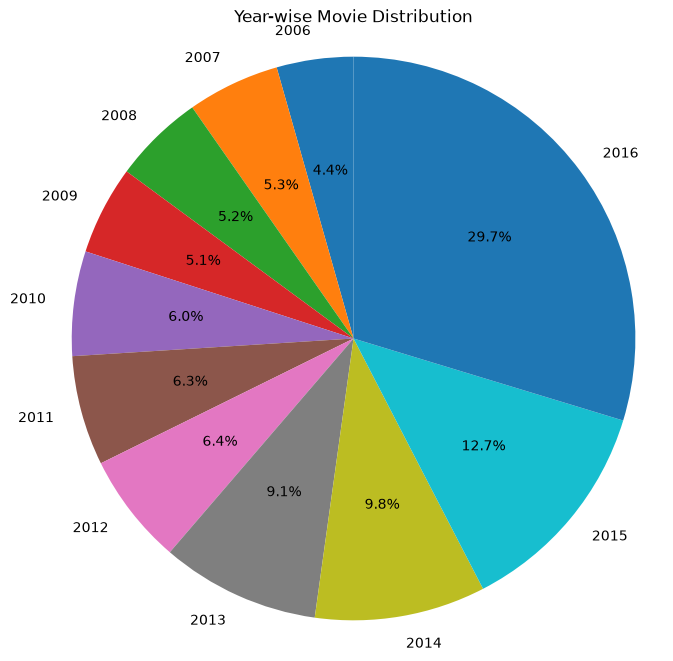

In [ ]:
year_counts = df['Year'].value_counts().sort_index()

plt.figure(figsize=(8, 8))
plt.pie(
    year_counts.values,
    labels=year_counts.index,
    autopct='%1.1f%%',
    startangle=90
)
plt.title('Year-wise Movie Distribution')
plt.axis('equal')
plt.show()

C:\Users\naman yadav\AppData\Local\Temp\ipykernel_60492\3648879304.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=genre_votes, x='Genre', y='Votes', palette='viridis')


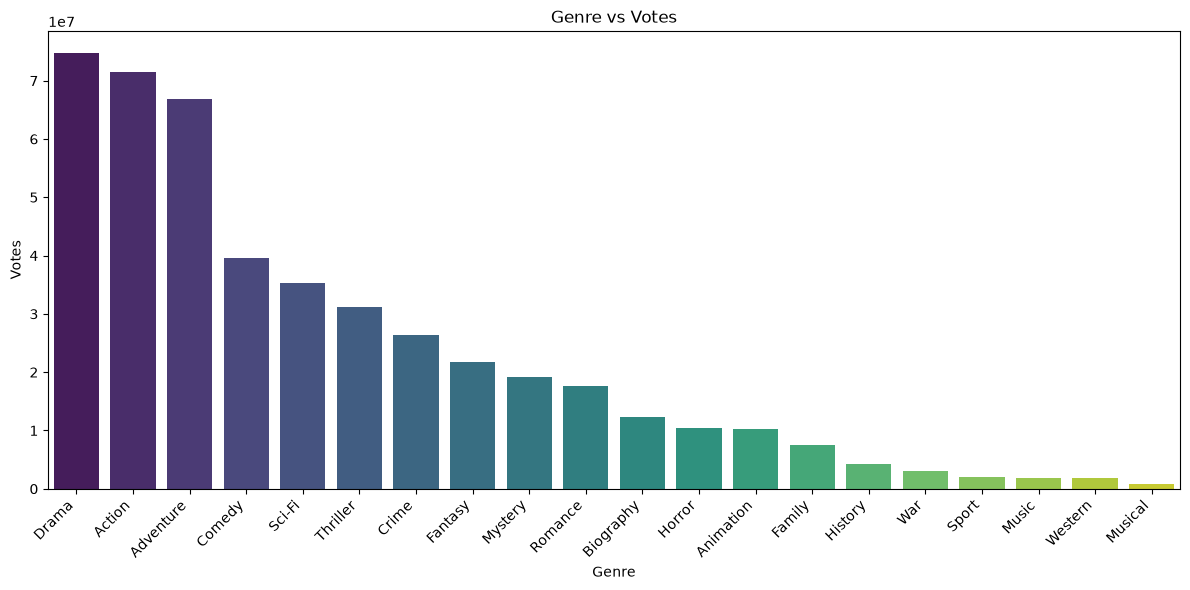

In [ ]:
genre_votes = (
    df.assign(Genre=df['Genre'].str.split(','))
      .explode('Genre')
      .groupby('Genre', as_index=False)['Votes']
      .sum()
      .sort_values('Votes', ascending=False)
)

plt.figure(figsize=(12, 6))
sns.barplot(data=genre_votes, x='Genre', y='Votes', palette='viridis')
plt.title('Genre vs Votes')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

C:\Users\naman yadav\AppData\Local\Temp\ipykernel_60492\4278737794.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=genre_revenue, x='Revenue (Millions)', y='Genre', ax=axes[0], palette='viridis')
C:\Users\naman yadav\AppData\Local\Temp\ipykernel_60492\4278737794.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=director_revenue, x='Revenue (Millions)', y='Director', ax=axes[1], palette='magma')
C:\Users\naman yadav\AppData\Local\Temp\ipykernel_60492\4278737794.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=direct

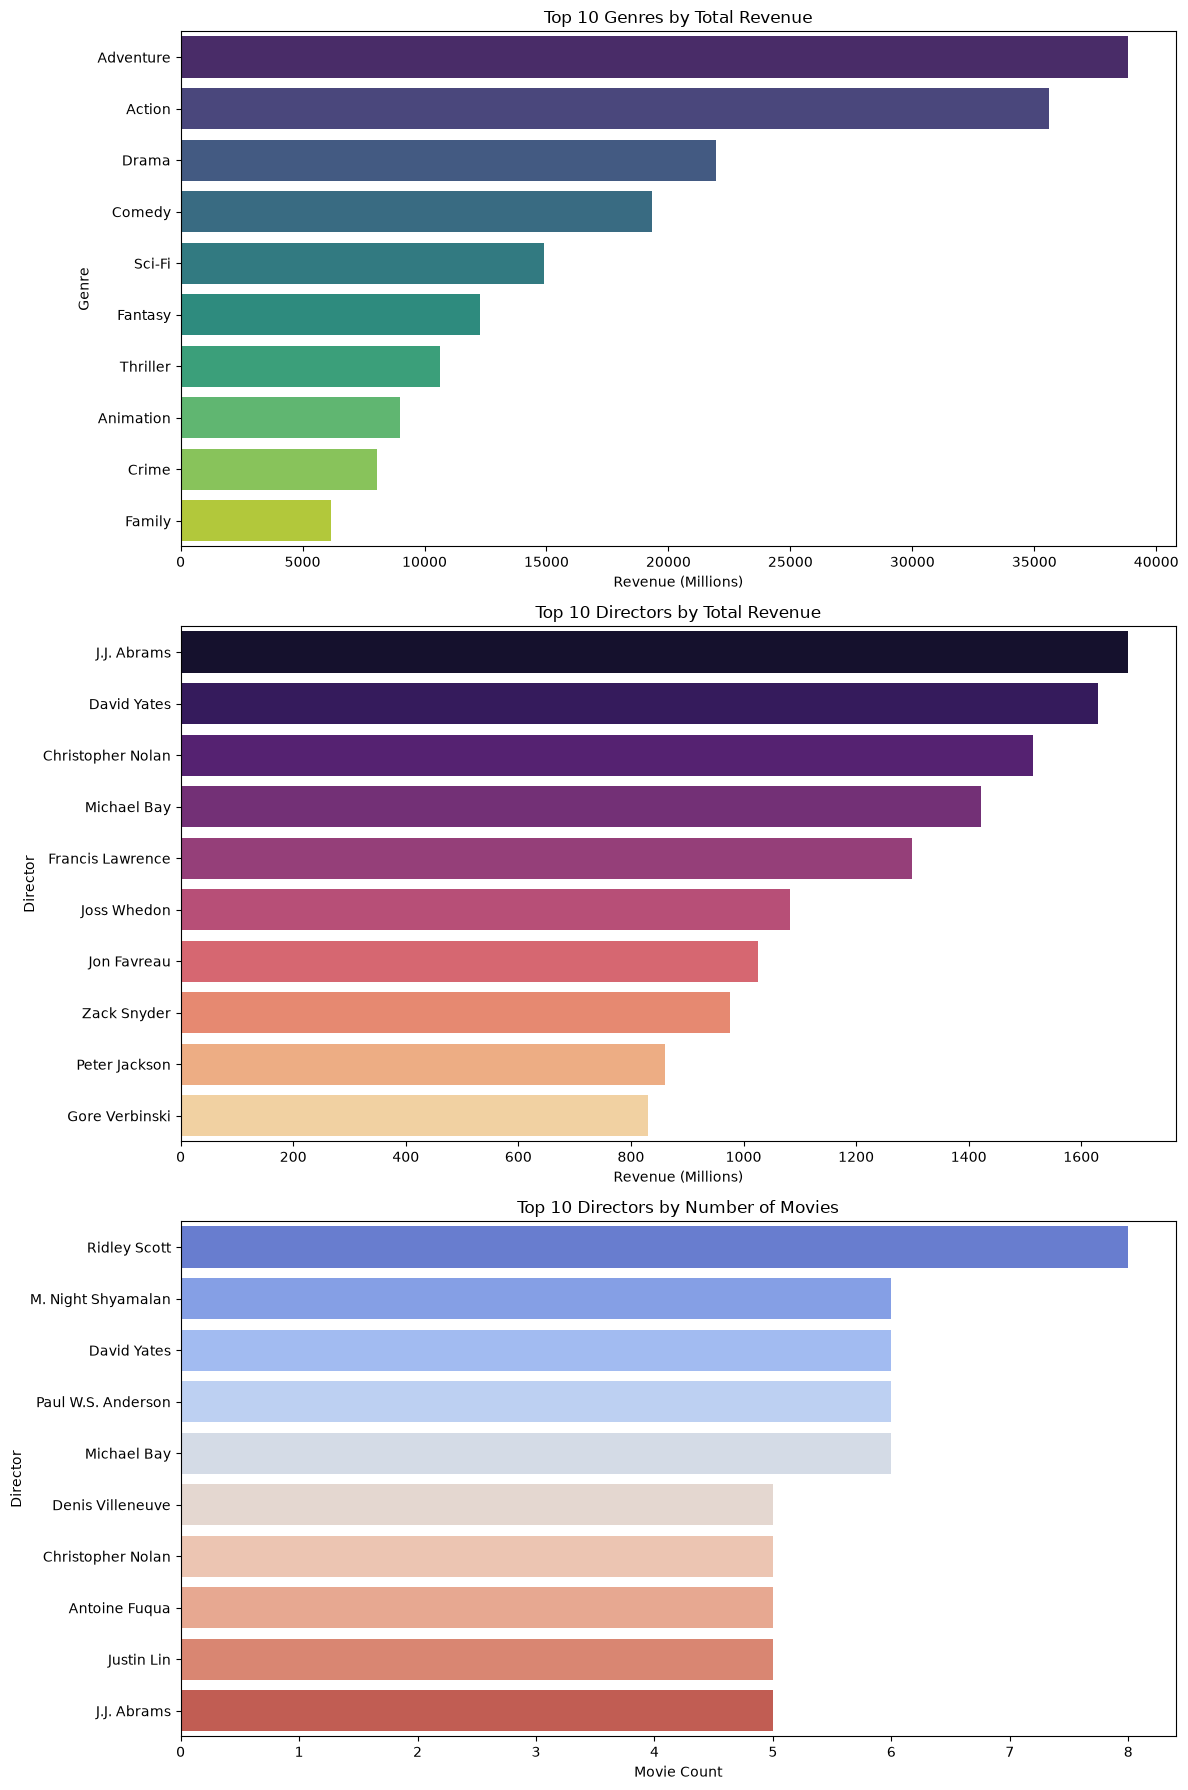

In [ ]:
# Ensure revenue is numeric
df['Revenue (Millions)'] = pd.to_numeric(df['Revenue (Millions)'], errors='coerce')

# 1) Genre vs Revenue (top 10 genres by total revenue)
genre_revenue = (
    df.assign(Genre=df['Genre'].str.split(','))
      .explode('Genre')
      .assign(Genre=lambda x: x['Genre'].str.strip())
      .groupby('Genre', as_index=False)['Revenue (Millions)']
      .sum()
      .sort_values('Revenue (Millions)', ascending=False)
      .head(10)
)

# 2) Director vs Revenue (top 10 directors by total revenue)
director_revenue = (
    df.groupby('Director', as_index=False)['Revenue (Millions)']
      .sum()
      .sort_values('Revenue (Millions)', ascending=False)
      .head(10)
)

# 3) Directors vs Movies (top 10 directors by movie count)
director_movies = (
    df['Director'].value_counts()
      .head(10)
      .sort_values(ascending=False)
      .reset_index()
)
director_movies.columns = ['Director', 'Movie Count']

fig, axes = plt.subplots(3, 1, figsize=(12, 18))

sns.barplot(data=genre_revenue, x='Revenue (Millions)', y='Genre', ax=axes[0], palette='viridis')
axes[0].set_title('Top 10 Genres by Total Revenue')

sns.barplot(data=director_revenue, x='Revenue (Millions)', y='Director', ax=axes[1], palette='magma')
axes[1].set_title('Top 10 Directors by Total Revenue')

sns.barplot(data=director_movies, x='Movie Count', y='Director', ax=axes[2], palette='coolwarm')
axes[2].set_title('Top 10 Directors by Number of Movies')

plt.tight_layout()
plt.show()

In [70]:
df.shape

(1000, 12)